# [A practical introduction to machine learning for hearing science](https://github.com/msaddler/auditory_machine_learning)

<a href="https://colab.research.google.com/github/msaddler/auditory_machine_learning/blob/main/DEVELOPMENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Copyright (c) 2026 Mark R. Saddler. MIT license.

## Setup

Import standard Python packages.

In [70]:
import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy as np
import torch
import tqdm


If running this notebook in Google Colab, run the cell below to clone the [**`auditory_machine_learning`**](https://github.com/msaddler/auditory_machine_learning) repository into the current runtime.

In [71]:
# !git clone https://github.com/msaddler/auditory_machine_learning.git
# %cd auditory_machine_learning
# !ls -1


Import [**datasets.py**](https://github.com/msaddler/auditory_model_tutorial/blob/main/datasets.py), [**modules.py**](https://github.com/msaddler/auditory_model_tutorial/blob/main/modules.py), and [**utils.py**](https://github.com/msaddler/auditory_machine_learning/blob/main/utils.py) as Python modules. The classes and functions in these scripts can be called from this notebook once imported.

In [72]:
import datasets
import modules
import utils


Check if a GPU (optional) is available in the current runtime and define the `device` variable.

In [73]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device


device(type='cuda', index=0)

## Introduction

This repository includes a small dataset of example sound files (speech waveforms stored as wav files), which can be loaded and played in the notebook.

In [74]:
synthetic_vowel_dataset = datasets.SyntheticVowels(
    sr=20000,  # Sampling rate in Hz
    dur=0.250,  # Stimulus duration in s
    dbspl_list=[60],  # Stimulus levels in dB SPL
    f0_list=[100],  # Fundamental frequencies in Hz
)

# Iterate over the dataset and play 10 example vowels
for itr in range(10):
    example = synthetic_vowel_dataset[itr]
    sr = example["sr"]
    x = example["signal"]
    print(f'{example["vowel"]}  |  {example["vowel_str"]}  |  f0 = {example["f0"]}Hz')
    ipd.display(ipd.Audio(rate=sr, data=x))


0  |  /i/ (heed)  |  f0 = 100.0Hz


1  |  /I/ (hid)  |  f0 = 100.0Hz


2  |  /e/ (hayed)  |  f0 = 100.0Hz


3  |  /eps/ (head)  |  f0 = 100.0Hz


4  |  /ae/ (had)  |  f0 = 100.0Hz


5  |  /a/ (hod)  |  f0 = 100.0Hz


6  |  /^/ (hud)  |  f0 = 100.0Hz


7  |  /o/ (hoed)  |  f0 = 100.0Hz


8  |  /U/ (hood)  |  f0 = 100.0Hz


9  |  /u/ (who'd)  |  f0 = 100.0Hz


The [**`utils`**](https://github.com/msaddler/auditory_model_tutorial/blob/main/utils.py) module contains helper functions for manipulating and visualizing audio signals. Use the `utils.make_spectrogram_plot` function to plot the sound waveform and spectrogram of the file loaded above.

In [101]:
cochlear_model = modules.CochlearModel(
    sr_input=20000,                     # Sampling rate of input audio (Hz)
    sr_output=10000,                    # Sampling rate of output auditory nerve representations (Hz)
    fir_dur=0.05,                       # Cochlear filterbank FIR duration (s)
    cfs=utils.erbspace(8e1, 8e3, 100),  # Characteristic frequencies (Hz)
    bw_mult=1.0,                        # Scaling factor to broaden/narrow bandwidths of cochlear filters
    ihc_lowpass_cutoff=3000,            # Inner hair cell lowpass filter cutoff determines phase locking limit (Hz)
    ihc_lowpass_order=7,                # Inner hair cell lowpass filter order (int)
    threshold=0.0,                      # Absolute threshold of auditory nerve fibers (dB SPL)
    dynamic_range=80.0,                 # Dynamic range of auditory nerve fibers (dB)
    dtype=torch.float32,                # Default PyTorch datatype
)
cochlear_model


CochlearModel(
  (cochlear_filterbank): GammatoneFilterbank()
  (half_wave_rectification): ReLU()
  (ihc_lowpass_filter): IHCLowpassFilter()
  (rate_level_function): SigmoidRateLevelFunction()
)

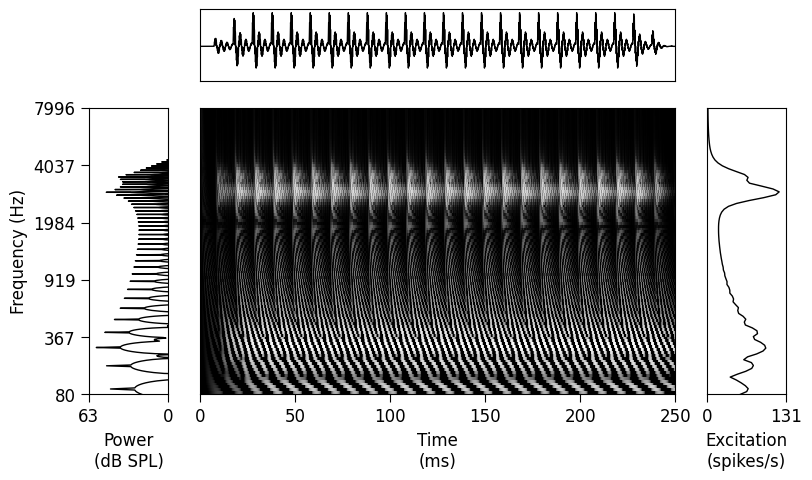

In [102]:
x = synthetic_vowel_dataset[0]["signal"]
x_nervegram = cochlear_model(x).numpy()

fig, ax_arr = utils.make_nervegram_plot(
    waveform=x,
    nervegram=x_nervegram,
    sr_waveform=cochlear_model.sr_input,
    sr_nervegram=cochlear_model.sr_output,
    cfs=cochlear_model.cfs,
)
plt.show()


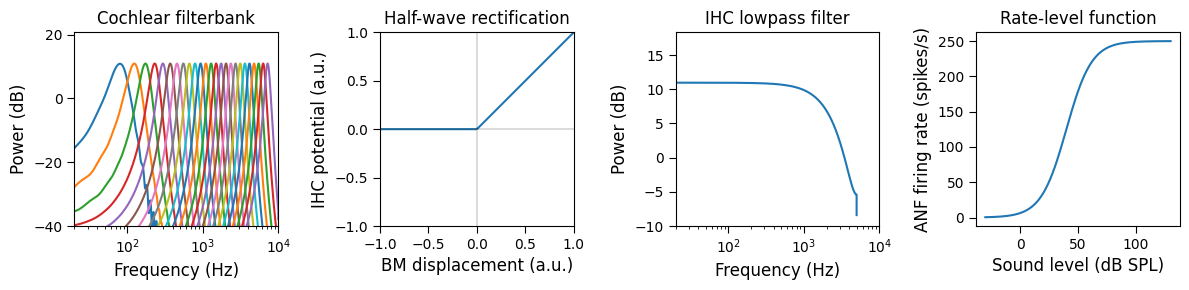

In [103]:
fig, ax_arr = plt.subplots(nrows=1, ncols=4, figsize=(12, 3))

impulse = torch.zeros(int(cochlear_model.sr_input))
impulse[0] = 1

# Plot frequency response of cochlear filterbank (linear Gammatone filterbank)
cochlear_filterbank_impulse_response = cochlear_model.cochlear_filterbank(impulse)
fxx, pxx = utils.periodogram(
    cochlear_filterbank_impulse_response.numpy(),
    cochlear_model.sr_input,
)
ax_arr[0].plot(fxx, pxx[::4].T)
ax_arr[0] = utils.format_axes(
    ax_arr[0],
    str_title="Cochlear filterbank",
    str_xlabel="Frequency (Hz)",
    str_ylabel="Power (dB)",
    xscale="log",
    xlimits=[20, cochlear_model.sr_input // 2],
    ylimits=[-40, None],
    fontsize_ticks=10,
)

# Plot IHC transduction function (crudely modeled as half-wave rectification)
x = torch.linspace(-1, 1, 100)
y = cochlear_model.half_wave_rectification(x)
ax_arr[1].plot(x.numpy(), y.numpy())
ax_arr[1].axvline(0, color="k", lw=0.2)
ax_arr[1].axhline(0, color="k", lw=0.2)
ax_arr[1].axis("square")
utils.format_axes(
    ax_arr[1],
    xlimits=[-1, 1],
    ylimits=[-1, 1],
    str_xlabel="BM displacement (a.u.)",
    str_ylabel="IHC potential (a.u.)",
    str_title="Half-wave rectification",
    fontsize_ticks=10,
)

# Plot frequency response of IHC lowpass filter (sets upper limit of phase locking)
ihc_lowpass_filter_impulse_response = cochlear_model.ihc_lowpass_filter(impulse)
fxx, pxx = utils.periodogram(
    ihc_lowpass_filter_impulse_response.numpy(),
    cochlear_model.sr_output,
)
ax_arr[2].plot(fxx, pxx)
ax_arr[2] = utils.format_axes(
    ax_arr[2],
    str_title="IHC lowpass filter",
    str_xlabel="Frequency (Hz)",
    str_ylabel="Power (dB)",
    xscale="log",
    xlimits=[20, cochlear_model.sr_input // 2],
    ylimits=[-10, None],
    fontsize_ticks=10,
)

# Plot auditory nerve rate-level function (determines threshold and dynamic range)
x_db = torch.arange(-30, 131)
x_pa = 20e-6 * (10 ** (x_db / 20))
y = cochlear_model.rate_level_function(x_pa)
ax_arr[3].plot(x_db.numpy(), y.numpy())
ax_arr[3] = utils.format_axes(
    ax_arr[3],
    str_xlabel="Sound level (dB SPL)",
    str_ylabel="ANF firing rate (spikes/s)",
    str_title="Rate-level function",
    fontsize_ticks=10,
)

plt.tight_layout()
plt.show()


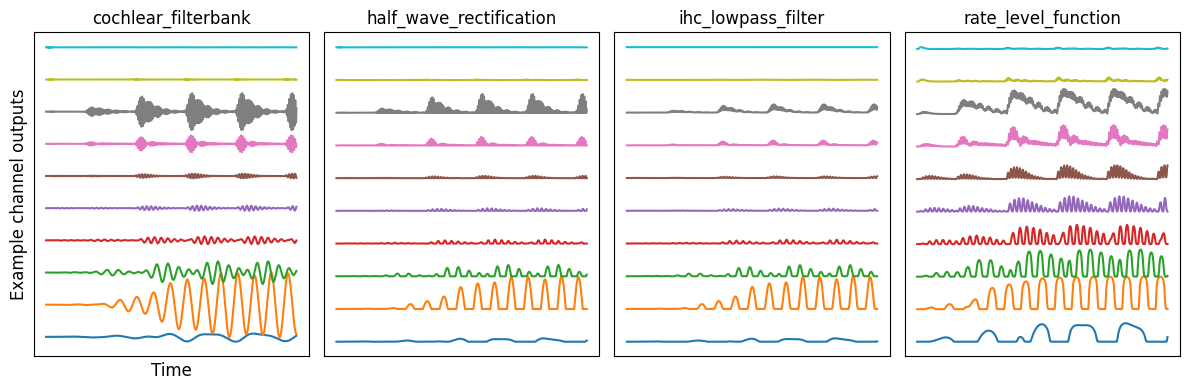

In [104]:
x = torch.as_tensor(synthetic_vowel_dataset[0]["signal"])

list_model_stage_name = [
    "cochlear_filterbank",
    "half_wave_rectification",
    "ihc_lowpass_filter",
    "rate_level_function",
]

# Iteratively apply cochlear model stages and visualize output after each stage
fig, ax_arr = plt.subplots(nrows=1, ncols=len(list_model_stage_name), figsize=(12, 4))
for itr_ax, model_stage_name in enumerate(list_model_stage_name):
    model_stage = getattr(cochlear_model, model_stage_name)
    x = model_stage(x)

    # Plot only a handful of the model frequency channels
    # (outputs are also truncated and peak-normalized)
    x_to_show = x[5::10, 0 : (x.shape[1] // 5)].numpy()
    x_to_show = x_to_show / np.max(x_to_show)

    ax = ax_arr[itr_ax]
    for itr_channel in range(x_to_show.shape[0]):
        ax.plot(x_to_show[itr_channel] + itr_channel)
    ax = utils.format_axes(
        ax,
        str_title=model_stage_name,
        xticks=[],
        yticks=[],
        str_xlabel="Time" if itr_ax == 0 else None,
        str_ylabel="Example channel outputs" if itr_ax == 0 else None,
    )
plt.tight_layout()
plt.show()


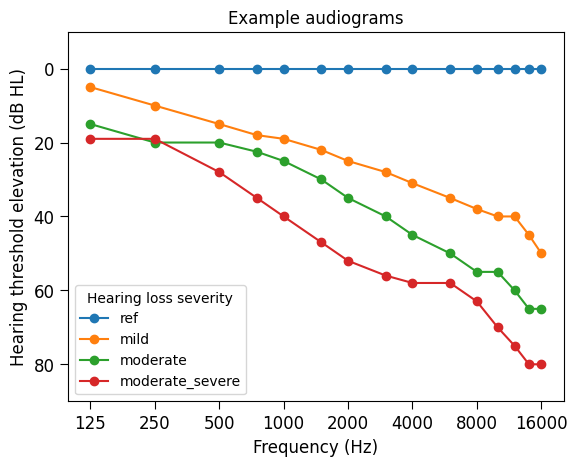

In [105]:
fig, ax = plt.subplots()
for severity in ["ref", "mild", "moderate", "moderate_severe"]:
    audiogram = utils.get_example_audiogram(severity)
    ax.plot(audiogram["freq"], audiogram["dbhl"], marker="o", label=severity)
ax.legend(title="Hearing loss severity")
ax = utils.format_axes(
    ax,
    xscale="log",
    ylimits=[90, -10],
    xticks=[125, 250, 500, 1000, 2000, 4000, 8000, 16000],
    xticklabels=[125, 250, 500, 1000, 2000, 4000, 8000, 16000],
    xticks_minor=[],
    str_xlabel="Frequency (Hz)",
    str_ylabel="Hearing threshold elevation (dB HL)",
    str_title="Example audiograms",
)
plt.show()


In the healthy ear, **outer hair cells (OHCs) act as a cochlear amplifier**, boosting responses to quiet sounds. Sensorineural hearing loss often involves the death or dysfunction of OHCs, resulting in reduced sensitivity to quiet sounds (elevated thresholds) and a smaller dynamic range. We can simulate these effects by adjusting the rate-level function parameters.

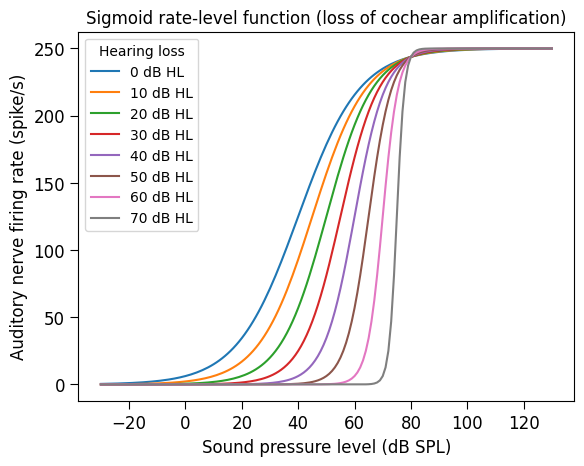

In [106]:
fig, ax = plt.subplots()
healthy_threshold = 0.0
healthy_dynamic_range = 80.0
for dbhl in np.arange(0, 71, 10):
    rate_level_function = modules.SigmoidRateLevelFunction(
        threshold=healthy_threshold + dbhl,  # Simply increase the threshold
        dynamic_range=healthy_dynamic_range - dbhl,  # And decrease the dynamic range
    )
    x_db = torch.arange(-30, 131)
    x_pa = 20e-6 * (10 ** (x_db / 20))
    y = rate_level_function(x_pa)
    ax.plot(x_db.numpy(), y.numpy(), label=f"{dbhl} dB HL")
ax.legend(title="Hearing loss")
ax = utils.format_axes(
    ax,
    str_xlabel="Sound pressure level (dB SPL)",
    str_ylabel="Auditory nerve firing rate (spike/s)",
    str_title="Sigmoid rate-level function (loss of cochear amplification)",
)
plt.show()


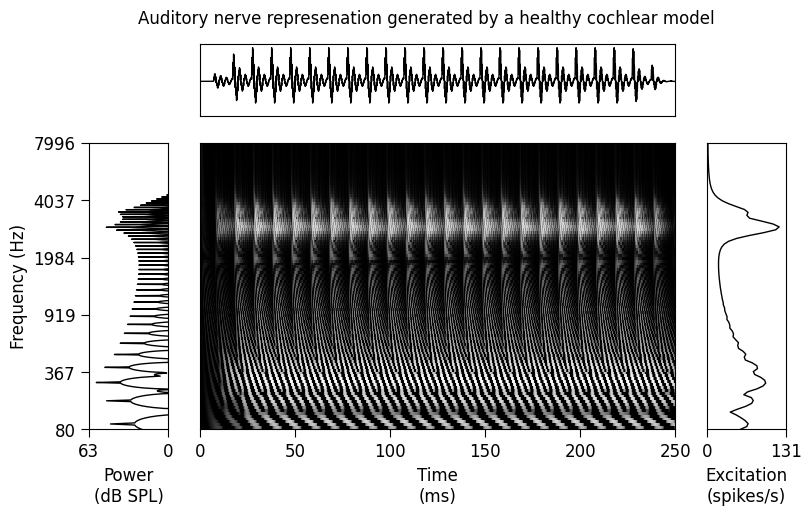

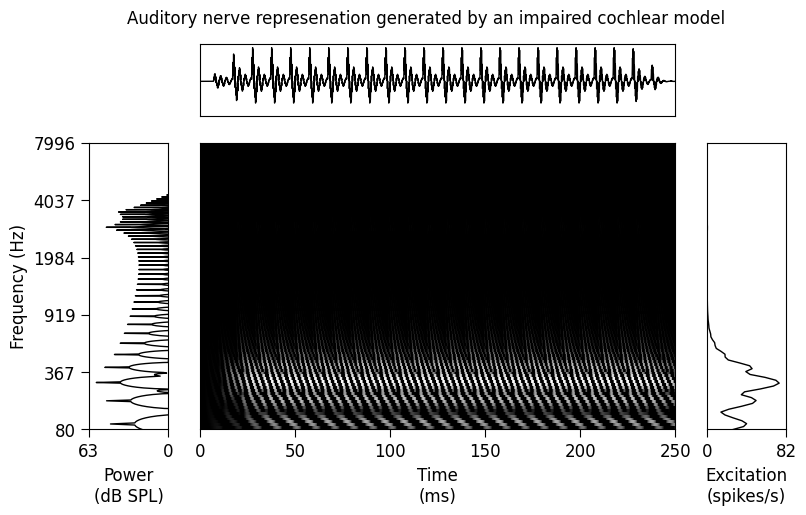

In [107]:
audiogram_healthy = utils.get_example_audiogram("ref")
audiogram_impaired = utils.get_example_audiogram("moderate_severe")
cochlear_model_healthy = modules.AudiogramMatchedCochlearModel(audiogram=audiogram_healthy)
cochlear_model_impaired = modules.AudiogramMatchedCochlearModel(audiogram=audiogram_impaired)

synthetic_vowel_dataset = datasets.SyntheticVowels(dbspl_list=[60], f0_list=[100])
x = synthetic_vowel_dataset[0]["signal"]
x_nervegram_healthy = cochlear_model_healthy(x).numpy()
x_nervegram_impaired = cochlear_model_impaired(x).numpy()

fig, ax_arr = utils.make_nervegram_plot(
    waveform=x,
    nervegram=x_nervegram_healthy,
    sr_waveform=cochlear_model_healthy.sr_input,
    sr_nervegram=cochlear_model_healthy.sr_output,
    cfs=cochlear_model_healthy.cfs,
)
fig.suptitle("Auditory nerve represenation generated by a healthy cochlear model", y=0.95)
plt.show()

fig, ax_arr = utils.make_nervegram_plot(
    waveform=x,
    nervegram=x_nervegram_impaired,
    sr_waveform=cochlear_model_impaired.sr_input,
    sr_nervegram=cochlear_model_impaired.sr_output,
    cfs=cochlear_model_impaired.cfs,
)
fig.suptitle("Auditory nerve represenation generated by an impaired cochlear model", y=0.95)
plt.show()


Get a sense for how fast the cochlear model can run on the current device.

In [108]:
cochlear_model = modules.AudiogramMatchedCochlearModel(audiogram="ref").to(device)

dataset = datasets.SyntheticVowels()

progress_bar = tqdm.tqdm(range(200))  # tqdm.tqdm wraps an iterable and displays a progress bar
for itr in progress_bar:
    x = dataset[itr]["signal"]
    x = torch.as_tensor(x).to(device)
    x_nervegram = cochlear_model(x)
    progress_bar.set_postfix({"current_iteration": itr})


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 872.16it/s, current_iteration=199]


## Hearing aid optimization objective

A reasonable objective for a hearing aid would be to process audio in such a way that the auditory nerve representation of an impaired ear is maximally similar to that of a healthy ear. How can we implement this notion quantitatively as a *loss function*?

Define a `loss_function` that takes as input an unprocessed sound waveform `x` and a processed sound_waveform `x_aided`. The function should return some [**measure of distance**](https://pytorch.org/docs/stable/nn.functional.html#loss-functions) between the healthy auditory nerve representation of `x` and the impaired auditory nerve representation of `x_aided`.


In [118]:
cochlear_model_healthy = modules.AudiogramMatchedCochlearModel(audiogram="ref").to(device)
cochlear_model_impaired = modules.AudiogramMatchedCochlearModel(audiogram="moderate_severe").to(device)

def cochlear_model_loss_function(x, x_aided):
    x_nervegram_healthy = cochlear_model_healthy(x)
    x_nervegram_impaired = cochlear_model_impaired(x_aided)
    loss = torch.nn.functional.mse_loss(x_nervegram_healthy, x_nervegram_impaired)
    return loss


We will first consider the **simplest possible hearing aid**: linear amplification applied to the entire sound waveform. Here, there is only a single parameter to optimize (the gain), so we can easily find the optimal value with brute force.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:04<00:00,  3.44it/s, loss=7704.85, gain_db=47.5]


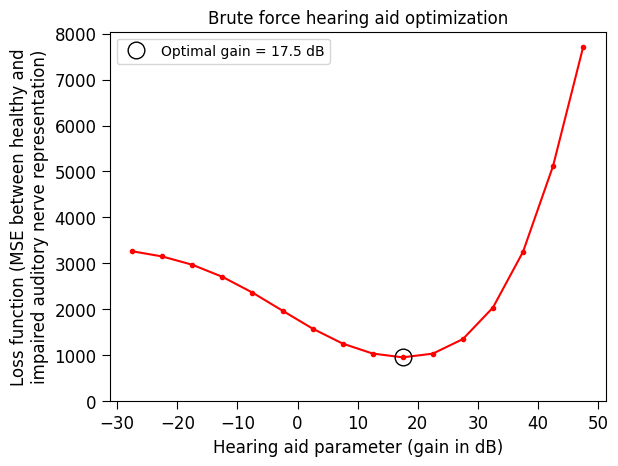

In [84]:
dataset_train = datasets.WavFiles(filenames="data/???.wav", dbspl=60)
dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=16, shuffle=False)

list_gain_db = np.arange(-27.5, 52.5, 5)
list_loss = []

progress_bar = tqdm.tqdm(list_gain_db)
for gain_db in progress_bar:
    loss = 0
    for step, example in enumerate(dataloader_train):
        x = example["signal"].to(device)
        x_aided = np.power(10, gain_db / 20) * x
        batch_loss = cochlear_model_loss_function(x, x_aided).item()
        loss += batch_loss
    loss = loss / len(dataloader_train)
    list_loss.append(loss)
    progress_bar.set_postfix({
        "loss": f"{loss:.2f}",
        "gain_db": gain_db,
    })

best_gain_db = list_gain_db[np.argmin(list_loss)]

fig, ax = plt.subplots()
ax.plot(list_gain_db, list_loss, marker=".", color="r", ls="-")
ax.plot(
    best_gain_db,
    np.min(list_loss),
    marker="o",
    ms=12,
    ls="",
    mfc="none",
    color="k",
    label=f"Optimal gain = {best_gain_db} dB",
)
ax.legend()
utils.format_axes(
    ax,
    str_title="Brute force hearing aid optimization",
    str_xlabel="Hearing aid parameter (gain in dB)",
    str_ylabel="Loss function (MSE between healthy and\nimpaired auditory nerve representation)",
    ylimits=[0, None],
)
plt.show()


## Gradient-based hearing aid optimization 

We will optimize the parameters of the hearing aid using gradient descent to minimize our loss function.

**This cell will run extremely slowly without GPU acceleration**. If a GPU is not available, use a smaller dataset by truncating the number of examples and/or the length of the stimuli.


In [85]:
class OneParameterHearingAid(torch.nn.Module):
    def __init__(self, initial_gain_db=0):
        """
        Initialize the hearing aid model.
        """
        super().__init__()
        self.gain_db = torch.nn.parameter.Parameter(
            data=torch.ones([]) * initial_gain_db,
            requires_grad=True,
        )

    def forward(self, x):
        """
        Apply hearing aid processing to an input sound `x`.
        """
        return x * torch.pow(10, self.gain_db / 20)

    def __repr__(self):
        """ """
        display_str = "HearingAid({})".format(
            ", ".join([
                f"{n}: {p.detach().cpu().numpy():.2f}"
                for n, p in self.named_parameters()
            ])
        )
        return display_str


dataset_train = datasets.WavFiles(filenames="data/???.wav", dbspl=60)
dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=8, shuffle=True)

hearing_aid = OneParameterHearingAid(initial_gain_db=0)
hearing_aid = hearing_aid.train(True).to(device)
trainable_parameters = list(hearing_aid.parameters())
optimizer = torch.optim.Adam(trainable_parameters, lr=1e-0)

progress_bar = tqdm.tqdm(range(10))
for epoch in progress_bar:
    epoch_loss = 0
    for step, example in enumerate(dataloader_train):
        x = example["signal"].to(device)
        x_aided = hearing_aid(x)
        loss = cochlear_model_loss_function(x, x_aided)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        progress_bar.set_postfix({
            "loss": f"{epoch_loss / (step + 1):.2f}",
            "hearing_aid": str(hearing_aid),
        })
print(hearing_aid)


100%|██████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:07<00:00,  1.32it/s, loss=926.65, hearing_aid=HearingAid(gain_db: 17.65)]

HearingAid(gain_db: 17.65)


Visualize the resulting auditory nerve representations.

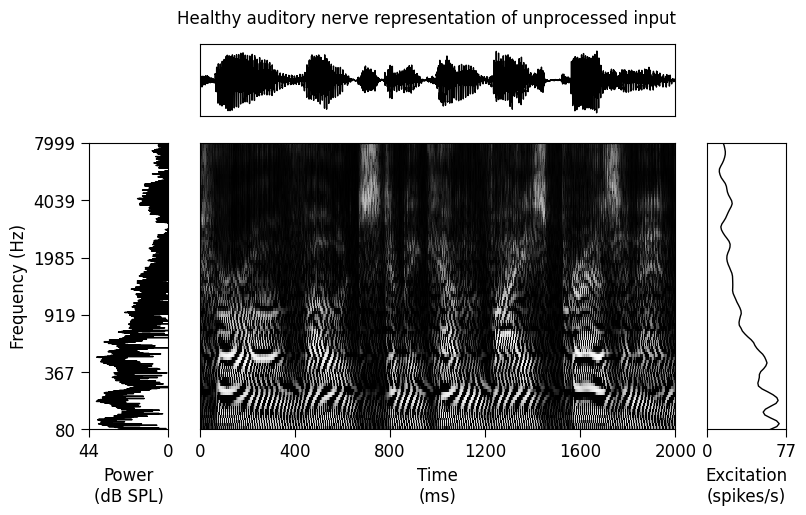

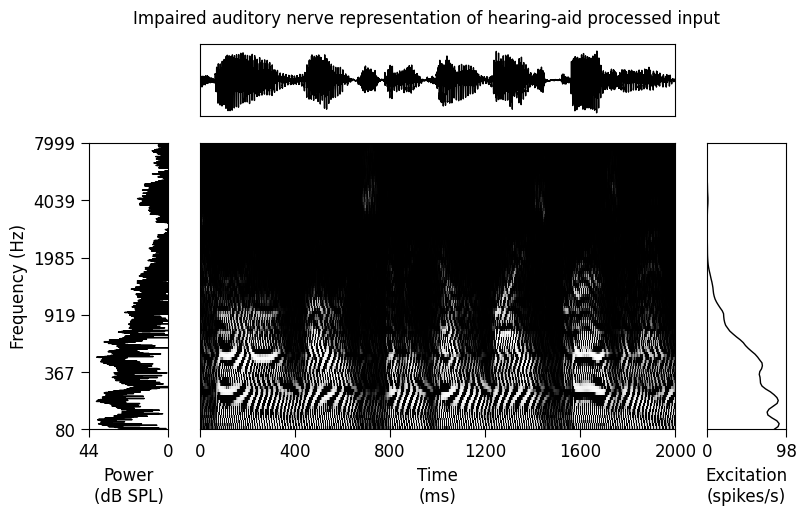

In [86]:
waveform = x[0]
nervegram_healthy = cochlear_model_healthy(waveform)
nervegram_impaired = cochlear_model_impaired(np.power(10, best_gain_db / 20) * waveform)
nervegram_impaired = cochlear_model_impaired(hearing_aid(waveform))

fig, ax_arr = utils.make_nervegram_plot(
    waveform=waveform.detach().cpu().numpy(),
    nervegram=nervegram_healthy.detach().cpu().numpy(),
    sr_waveform=cochlear_model_healthy.sr_input,
    sr_nervegram=cochlear_model_healthy.sr_output,
    cfs=cochlear_model_healthy.cfs,
)
fig.suptitle("Healthy auditory nerve representation of unprocessed input", y=0.95)
plt.show()

fig, ax_arr = utils.make_nervegram_plot(
    waveform=waveform.detach().cpu().numpy(),
    nervegram=nervegram_impaired.detach().cpu().numpy(),
    sr_waveform=cochlear_model_impaired.sr_input,
    sr_nervegram=cochlear_model_impaired.sr_output,
    cfs=cochlear_model_impaired.cfs,
)
fig.suptitle("Impaired auditory nerve representation of hearing-aid processed input", y=0.95)
plt.show()


Real hearing losses are rarely uniform across all frequencies. How can we compensate for frequency-dependent hearing loss?

## Frequency-dependent amplification

One possibility is to build a hearing aid with frequency-specific gains. We can filter the input sound into different frequency channels, scale the channels with separate gains, and then sum the channels back together. The `modules.HalfCosineFilterbank` class is a reasonable filterbank for decomposing and reconstructing audio in this way.

/orcd/home/002/msaddler/projects/auditory_machine_learning/modules.py:483: RuntimeWarning: divide by zero encountered in log
  f = np.log(f)


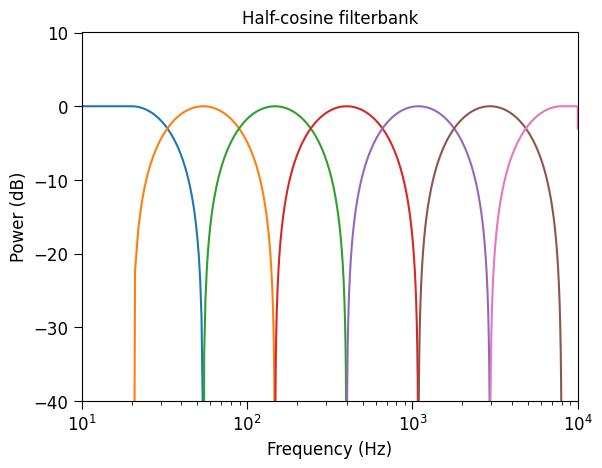

In [109]:
sr = 20000
filterbank = modules.HalfCosineFilterbank(
    sr=sr,
    cf_low=20,
    cf_high=8000,
    cf_num=7,
    scale="log",
    include_highpass=True,
    include_lowpass=True,
)

impulse = torch.zeros(int(sr))
impulse[0] = 1
impulse_response = filterbank(impulse).numpy()

fig, ax = plt.subplots()
fxx, pxx = utils.periodogram(impulse_response, sr)
ax.plot(fxx, pxx.T - pxx.max())
ax = utils.format_axes(
    ax,
    str_title="Half-cosine filterbank",
    str_xlabel="Frequency (Hz)",
    str_ylabel="Power (dB)",
    xscale="log",
    xlimits=[10, sr // 2],
    ylimits=[-40, None],
)
plt.show()


Since hearing aids can have many tunable parameters (e.g., frequency-specific gains), we need a more scalable optimization method than brute force. Implementing a hearing aid as a PyTorch model with learnable parameters unlocks the tools of machine learning -- we can use *gradient descent* to efficiently find parameter values that minimize our loss function.

Complete the `HearingAid` model class below. The `__init__` method has already been implemented. Only the `forward` method needs to be filled in.


In [89]:
class FrequencySpecificHearingAid(torch.nn.Module):
    def __init__(self, channels=7, initial_gain_db=0):
        """
        Initialize the hearing aid model.
        """
        super().__init__()
        self.filterbank = modules.HalfCosineFilterbank(
            sr=sr,
            cf_low=20,
            cf_high=sr / 2,
            cf_num=channels,
            scale="log",
            include_highpass=True,
            include_lowpass=True,
        )
        self.gain_db = torch.nn.parameter.Parameter(
            data=torch.ones(channels) * initial_gain_db,
            requires_grad=True,
        )

    def forward(self, x):
        """
        Apply hearing aid processing to an input sound `x`.
        """
        x = self.filterbank(x)
        gain_db = self.gain_db.view([-1, 1])
        while gain_db.ndim < x.ndim:
            gain_db = gain_db.unsqueeze(0)
        x = x * torch.pow(10, gain_db / 20)
        x = torch.sum(x, axis=-2)
        return x

    def __repr__(self):
        """ """
        display_str = "HearingAid({})".format(
            ", ".join([
                f"mean {n}: {p.mean().detach().cpu().numpy():.2f}"
                for n, p in self.named_parameters()
            ])
        )
        return display_str


dataset_train = datasets.WavFiles(filenames="data/???.wav", dbspl=60)
dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=8, shuffle=True)

hearing_aid = FrequencySpecificHearingAid(initial_gain_db=0)
hearing_aid = hearing_aid.train(True).to(device)
trainable_parameters = list(hearing_aid.parameters())
optimizer = torch.optim.Adam(trainable_parameters, lr=1e-0)

progress_bar = tqdm.tqdm(range(10))
for epoch in progress_bar:
    epoch_loss = 0
    for step, example in enumerate(dataloader_train):
        x = example["signal"].to(device)
        x_aided = hearing_aid(x)
        loss = cochlear_model_loss_function(x, x_aided)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        progress_bar.set_postfix({
            "loss": f"{epoch_loss / (step + 1):.2f}",
            "hearing_aid": str(hearing_aid),
        })
print(hearing_aid.gain_db)


100%|█████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:07<00:00,  1.30it/s, loss=408.65, hearing_aid=HearingAid(mean gain_db: 16.65)]

Parameter containing:
tensor([10.4958,  6.5524,  7.7092, 10.3964, 20.9138, 31.1498, 29.3078],
       device='cuda:0', requires_grad=True)


Test your `HearingAid` implementation by visualizing the impulse reponse.

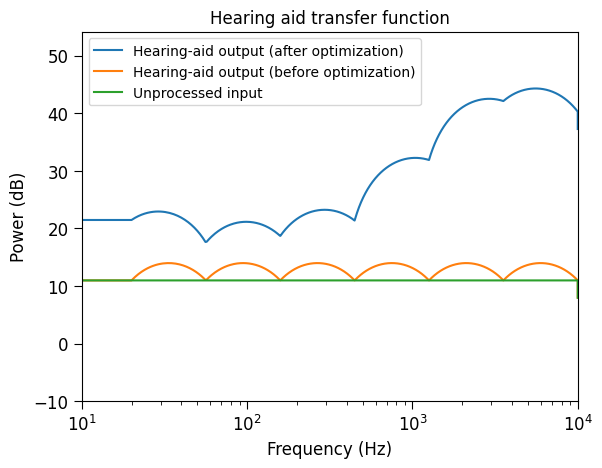

In [90]:
impulse = torch.zeros(int(hearing_aid.filterbank.sr)).to(device)
impulse[0] = 1
impulse_response = hearing_aid(impulse).detach().cpu().numpy()

before_hearing_aid = FrequencySpecificHearingAid(
    channels=hearing_aid.gain_db.shape[0],
    initial_gain_db=0,
).to(device)
before_impulse_response = before_hearing_aid(impulse).detach().cpu().numpy()

fig, ax = plt.subplots()
fxx, pxx = utils.periodogram(impulse_response, sr)
ax.plot(fxx, pxx, label="Hearing-aid output (after optimization)")
fxx, pxx = utils.periodogram(before_impulse_response, sr)
ax.plot(fxx, pxx, label="Hearing-aid output (before optimization)")
fxx, pxx = utils.periodogram(impulse.detach().cpu().numpy(), sr)
ax.plot(fxx, pxx, label="Unprocessed input")
ax.legend()
ax = utils.format_axes(
    ax,
    str_title="Hearing aid transfer function",
    str_xlabel="Frequency (Hz)",
    str_ylabel="Power (dB)",
    xscale="log",
    xlimits=[10, sr // 2],
    ylimits=[-10, None],
)
plt.show()


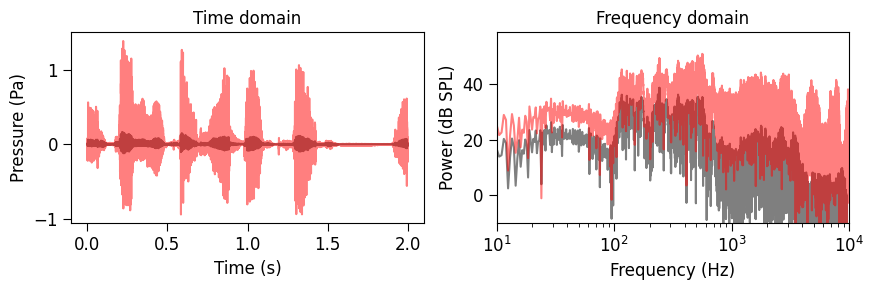

In [139]:
sr = dataset_train.sr
example_audio = torch.as_tensor(dataset_train[0]["signal"]).to(device)
example_audio_aided = hearing_aid(example_audio)
example_audio = example_audio.detach().cpu().numpy()
example_audio_aided = example_audio_aided.detach().cpu().numpy()

fig, ax_arr = plt.subplots(nrows=1, ncols=2, figsize=(9, 3))
t = np.arange(0, len(example_audio)) / sr
ax_arr[0].plot(t, example_audio, color="k", alpha=0.5)
ax_arr[0].plot(t, example_audio_aided, color="r", alpha=0.5)
ax_arr[0] = utils.format_axes(
    ax_arr[0],
    str_xlabel="Time (s)",
    str_ylabel="Pressure (Pa)",
    str_title="Time domain",
)
fxx, pxx = utils.periodogram(example_audio, sr)
fyy, pyy = utils.periodogram(example_audio_aided, sr)
ax_arr[1].plot(fxx, pxx, color="k", alpha=0.5)
ax_arr[1].plot(fyy, pyy, color="r", alpha=0.5)
ax_arr[1] = utils.format_axes(
    ax_arr[1],
    xscale="log",
    xlimits=[10, sr / 2],
    ylimits=[-10, None],
    str_xlabel="Frequency (Hz)",
    str_ylabel="Power (dB SPL)",
    str_title="Frequency domain",
)
plt.tight_layout()
plt.show()

ipd.display(ipd.Audio(rate=sr, data=example_audio))
ipd.display(ipd.Audio(rate=sr, data=example_audio_aided))


Visualize the resulting auditory nerve representations.

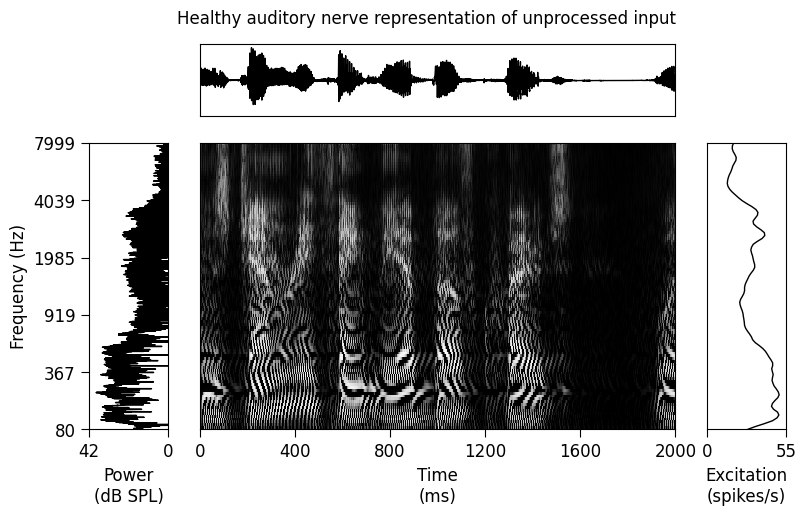

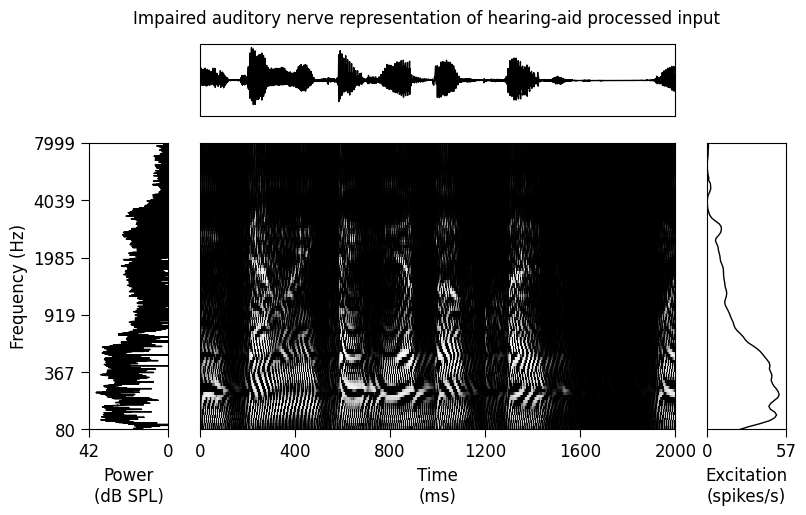

In [140]:
waveform = torch.as_tensor(example_audio).to(device)
nervegram_healthy = cochlear_model_healthy(waveform)
nervegram_impaired = cochlear_model_impaired(hearing_aid(waveform))

fig, ax_arr = utils.make_nervegram_plot(
    waveform=waveform.detach().cpu().numpy(),
    nervegram=nervegram_healthy.detach().cpu().numpy(),
    sr_waveform=cochlear_model_healthy.sr_input,
    sr_nervegram=cochlear_model_healthy.sr_output,
    cfs=cochlear_model_healthy.cfs,
)
fig.suptitle("Healthy auditory nerve representation of unprocessed input", y=0.95)
plt.show()

fig, ax_arr = utils.make_nervegram_plot(
    waveform=waveform.detach().cpu().numpy(),
    nervegram=nervegram_impaired.detach().cpu().numpy(),
    sr_waveform=cochlear_model_impaired.sr_input,
    sr_nervegram=cochlear_model_impaired.sr_output,
    cfs=cochlear_model_impaired.cfs,
)
fig.suptitle("Impaired auditory nerve representation of hearing-aid processed input", y=0.95)
plt.show()


In [93]:
# # Define the dataset (for time, we use only a small batch of speech signals)
# x = np.stack(
#     [sf.read("data/{:03d}.wav".format(_))[0] for _ in range(8)],
#     axis=0,
# )
# x = torch.as_tensor(x, device=device, dtype=torch.float32)
# print(f"Dataset shape: {x.shape}")

# # Define a PyTorch optimizer object and tell it which parameters to update
# optimizer = torch.optim.Adam(
#     params=list(hearing_aid.parameters()),
#     lr=1e-1,  # The learning rate is a hyperparameter (determines gradient descent step size)
# )

# # In the optimization loop, we iteratively compute the loss,
# # calculate the gradients with `loss.backward()`, and then
# # call `optimizer.step()` to update the parameters.
# progress_bar = tqdm.tqdm(range(500))
# for step in progress_bar:
#     optimizer.zero_grad()
#     x_aided = hearing_aid(x)
#     loss = loss_function(x=x, x_aided=x_aided)
#     loss.backward()
#     optimizer.step()
#     progress_bar.set_postfix({"loss": "{:0.4f}".format(loss.item())})

# print("hearing_aid parameters after optimization:")
# for n, p in hearing_aid.named_parameters():
#     print(n, p)


Another way to achieve frequency-specific linear gain is with convolution in the time domain. The `ConvolutionalHearingAid` class below convolves its inputs with a learnable FIR filter kernel.


In [129]:
class ConvolutionalHearingAid(torch.nn.Module):
    def __init__(self, kernel_size=101):
        """
        A simple hearing aid using a single 1D convolution.
        """
        super().__init__()
        self.conv = torch.nn.Conv1d(
            in_channels=1,
            out_channels=1,
            kernel_size=kernel_size,
            bias=False,
            padding=kernel_size // 2,
        )

    def forward(self, x):
        """
        Accepts:
            [time]
            [batch, time]
            [batch, 1, time]
        Returns:
            Same shape as input
        """
        original_ndim = x.ndim
        # Normalize to (batch, channel=1, time)
        if x.ndim == 1:
            x = x.unsqueeze(0).unsqueeze(0)  # [1, 1, T]
        elif x.ndim == 2:
            x = x.unsqueeze(1)  # [B, 1, T]
        elif x.ndim == 3:
            pass  # already [B, 1, T]
        else:
            raise ValueError("Input must have shape [time], [batch, time], or [batch, 1, time]")
        y = self.conv(x)
        # Restore original shape
        if original_ndim == 1:
            return y.squeeze(0).squeeze(0)  # [T]
        elif original_ndim == 2:
            return y.squeeze(1)  # [B, T]
        else:
            return y  # [B, 1, T]

    def __repr__(self):
        weight = self.conv.weight.detach().cpu()
        return f"HearingAid(weight_mean={weight.mean():.4f}, weight_mean={weight.std():.4f})"


dataset_train = datasets.WavFiles(filenames="data/???.wav", dbspl=60)
dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=8, shuffle=True)

hearing_aid = ConvolutionalHearingAid()
hearing_aid = hearing_aid.train(True).to(device)
trainable_parameters = list(hearing_aid.parameters())
optimizer = torch.optim.Adam(trainable_parameters, lr=1e-0)

progress_bar = tqdm.tqdm(range(20))
for epoch in progress_bar:
    epoch_loss = 0
    for step, example in enumerate(dataloader_train):
        x = example["signal"].to(device)
        x_aided = hearing_aid(x)
        loss = cochlear_model_loss_function(x, x_aided)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        progress_bar.set_postfix({
            "loss": f"{epoch_loss / (step + 1):.2f}",
            "hearing_aid": str(hearing_aid),
        })
print(hearing_aid.conv.weight)


100%|██████████████████████████████████████████████████████████████████| 20/20 [00:15<00:00,  1.29it/s, loss=923.68, hearing_aid=HearingAid(weight_mean=0.0860, weight_mean=3.2117)]

Parameter containing:
tensor([[[ 9.8617e-01, -4.3153e-01, -5.2844e-01, -6.6050e-01,  1.0671e-01,
           1.2433e+00,  6.5297e-01, -4.9881e-01, -7.5094e-01, -4.0394e-01,
          -1.5894e-01,  4.4808e-01,  6.1775e-01,  3.5633e-01,  7.1721e-02,
          -4.0340e-01, -6.5684e-01, -3.6817e-01,  4.7744e-01,  9.5891e-01,
           5.9913e-01, -8.2649e-02, -9.4876e-01, -8.3163e-01, -1.6980e-01,
           7.6362e-01,  7.8323e-01,  9.0086e-01,  4.5730e-01, -3.9991e-01,
          -1.1477e+00, -1.4352e+00,  2.2449e-01,  2.6328e+00,  3.2639e+00,
           3.1660e+00, -5.0896e+00, -1.3762e+01,  1.5799e+01,  2.8514e+00,
          -3.6360e+00, -1.7965e+00, -2.1116e-01,  1.2294e+00,  2.6680e-01,
          -2.2599e+00, -3.4263e+00, -2.4240e+00,  1.4443e+00,  5.6557e+00,
           7.1543e+00,  5.3085e+00,  1.3787e+00, -2.3489e+00, -3.5706e+00,
          -2.2748e+00, -3.0690e-01,  6.5306e-01,  9.1648e-01,  5.7020e-01,
          -4.1716e-01, -8.3531e-01, -3.9404e-01,  6.4603e-02,  1.3071e+00,
   

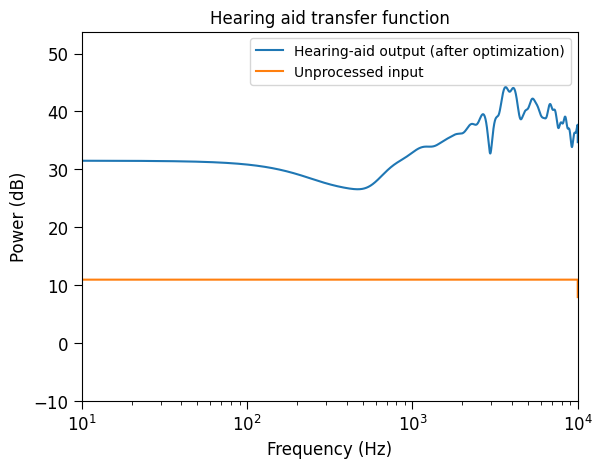

In [130]:
sr = dataset_train.sr
impulse = torch.zeros(int(sr)).to(device)
impulse[0] = 1
impulse_response = hearing_aid(impulse).detach().cpu().numpy()

fig, ax = plt.subplots()
fxx, pxx = utils.periodogram(impulse_response, sr)
ax.plot(fxx, pxx, label="Hearing-aid output (after optimization)")
fxx, pxx = utils.periodogram(impulse.detach().cpu().numpy(), sr)
ax.plot(fxx, pxx, label="Unprocessed input")
ax.legend()
ax = utils.format_axes(
    ax,
    str_title="Hearing aid transfer function",
    str_xlabel="Frequency (Hz)",
    str_ylabel="Power (dB)",
    xscale="log",
    xlimits=[10, sr // 2],
    ylimits=[-10, None],
)
plt.show()


## **Ideas for additional exploration**

On first glance, the hearing aid with frequency-specific linear gains appears to do fairly well. The impaired auditory nerve representation of the hearing-aid-processed signal reasonably resembles the healthy auditory nerve representation of the unprocessed signal.

- But it is far from perfect -- linear amplification cannot compensate for the reduced dynamic range of the impaired ear. Can you design and optimize a hearing aid that further minimizes the loss function?

- In addition to elevating thresholds and reducing dynamic ranges, loss of OHCs also leads to broader cochlear frequency tuning. This can be simulated by specifying `bw_mult` in `modules.GammatoneFilterbank`. Can you design a hearing aid that helps compensate for this consequence of hearing loss?

- The "hearing aids" in this notebook are toy examples with simple signal processing and small numbers of parameters. With a bit more compute power and a larger dataset, the same approach can be used to optimize more complex audio-processing systems, such as deep artificial neural networks. See [**`torchaudio.models`**](https://pytorch.org/audio/main/models.html) for ready-to-use PyTorch neural network models.

- Here, our optimization objective is to restore healthy auditory nerve representations in a very simple model of the impaired auditory nerve. Is this a good "loss function" for a hearing aid? How might we improve upon it?


In [137]:
import torchaudio


class ConvTasNetHearingAid(torch.nn.Module):
    def __init__(self, **args):
        """
        Initialize the hearing aid model.

        ConvTasNet arguments are defined in the PyTorch documentation:
        https://pytorch.org/audio/main/generated/torchaudio.models.ConvTasNet.html
        """
        super().__init__()
        self.convtasnet = torchaudio.models.ConvTasNet(**args)

    def forward(self, x):
        """
        Apply the computations to an input sound `x`.
        
        ConvTasNet, a neural network designed for source separation
        takes input with shape [batch, channel==1, time] and returns
        output with shape [batch, channel==num_sources, time]. Here,
        we simply return the first output source as our hearing aid
        processed audio.
        """
        original_ndim = x.ndim
        if x.ndim == 1:
            x = x.unsqueeze(0).unsqueeze(0)  # [1, 1, T]
        elif x.ndim == 2:
            x = x.unsqueeze(1)  # [B, 1, T]
        else:
            raise ValueError("Input must have shape [time] or [batch, time]")
        y = self.convtasnet(x)[:, 0, :]
        if original_ndim == 1:
            return y.squeeze(0)
        return y


dataset_train = datasets.WavFiles(filenames="data/???.wav", dbspl=60)
dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=16, shuffle=True)

hearing_aid = ConvTasNetHearingAid()
hearing_aid = hearing_aid.train(True).to(device)
trainable_parameters = list(hearing_aid.parameters())
optimizer = torch.optim.Adam(trainable_parameters, lr=1e-3)

progress_bar = tqdm.tqdm(range(10))
for epoch in progress_bar:
    epoch_loss = 0
    for step, example in enumerate(dataloader_train):
        x = example["signal"].to(device)
        x_aided = hearing_aid(x)
        loss = cochlear_model_loss_function(x, x_aided)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        progress_bar.set_postfix({
            "loss": f"{epoch_loss / (step + 1):.2f}",
        })


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:34<00:00,  3.44s/it, loss=805.67]


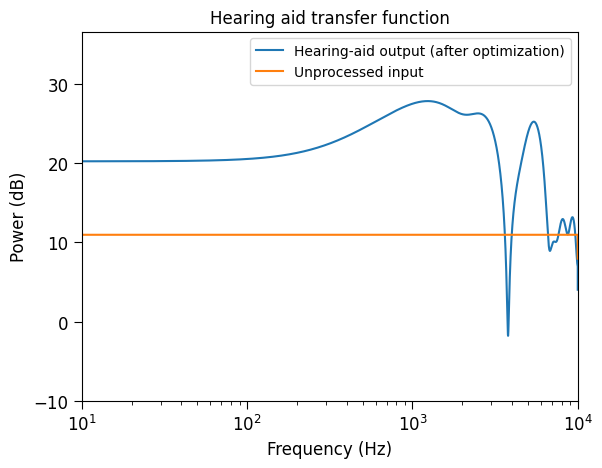

In [138]:
sr = dataset_train.sr
impulse = torch.zeros(int(sr)).to(device)
impulse[0] = 1
impulse_response = hearing_aid(impulse).detach().cpu().numpy()

fig, ax = plt.subplots()
fxx, pxx = utils.periodogram(impulse_response, sr)
ax.plot(fxx, pxx, label="Hearing-aid output (after optimization)")
fxx, pxx = utils.periodogram(impulse.detach().cpu().numpy(), sr)
ax.plot(fxx, pxx, label="Unprocessed input")
ax.legend()
ax = utils.format_axes(
    ax,
    str_title="Hearing aid transfer function",
    str_xlabel="Frequency (Hz)",
    str_ylabel="Power (dB)",
    xscale="log",
    xlimits=[10, sr // 2],
    ylimits=[-10, None],
)
plt.show()
